<h1 style="font-size: 70px;text-align: center; font-family:Copperplate; color: darkblue">Fake News Detection</h1>


In [2]:
#importing Libraries
import numpy as np
import pandas as pd
from matplotlib.pylab import plt
import seaborn as sns
from sklearn import metrics
from sklearn.metrics import confusion_matrix , classification_report
from sklearn.feature_extraction.text import CountVectorizer
#from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB, BernoulliNB
import re

In [3]:
df = pd.read_csv(r'C:\Users\emres\Documents\Gits\MLE\torch\data\WELFake_Dataset.csv')
df.head(10)

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1
5,5,About Time! Christian Group Sues Amazon and SP...,All we can say on this one is it s about time ...,1
6,6,DR BEN CARSON TARGETED BY THE IRS: “I never ha...,DR. BEN CARSON TELLS THE STORY OF WHAT HAPPENE...,1
7,7,HOUSE INTEL CHAIR On Trump-Russia Fake Story: ...,,1
8,8,Sports Bar Owner Bans NFL Games…Will Show Only...,"The owner of the Ringling Bar, located south o...",1
9,9,Latest Pipeline Leak Underscores Dangers Of Da...,"FILE – In this Sept. 15, 2005 file photo, the ...",1


In [4]:
df.describe()

,Unnamed: 0,label
count,72134.000000,72134.000000
mean,36066.500000,0.514404
std,20823.436496,0.499796
min,0.000000,0.000000
25%,18033.250000,0.000000
50%,36066.500000,1.000000
75%,54099.750000,1.000000
max,72133.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72134 entries, 0 to 72133
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  72134 non-null  int64 
 1   title       71576 non-null  object
 2   text        72095 non-null  object
 3   label       72134 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 2.2+ MB


In [6]:
y = df.label
print(f'Ratio of real and fake news:')
y.value_counts(normalize=True).rename({1: 'real', 0: 'fake'})

Ratio of real and fake news:


label
real    0.514404
fake    0.485596
Name: proportion, dtype: float64

In [7]:
df.drop(["Unnamed: 0"], axis=1, inplace=True)

In [8]:
df.isnull().sum()

title    558
text      39
label      0
dtype: int64

In [9]:
df = df.fillna('')

In [10]:
df.isnull().sum()

title    0
text     0
label    0
dtype: int64

In [11]:
df.nunique()

title    62348
text     62719
label        2
dtype: int64

In [12]:
df["title_text"] = df["title"] + df["text"]
df["body_len"] = df["title_text"].apply(lambda x: len(x) - x.count(" "))
df.head()

,title,text,label,title_text,body_len
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,4222
1,,Did they post their votes for Hillary already?,1,Did they post their votes for Hillary already?,39
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,299
3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0,"Bobby Jindal, raised Hindu, uses story of Chri...",6811
4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1,SATAN 2: Russia unvelis an image of its terrif...,1668


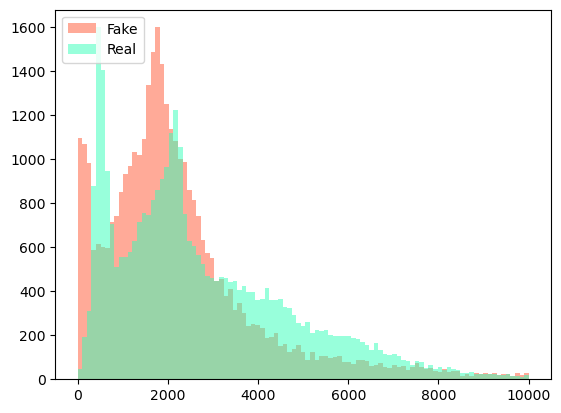

np.float64(2613.357462405002)

In [13]:
bins = np.linspace(0, 10000, 100)

plt.hist(df[df["label"]== 1]["body_len"], bins, alpha=0.5, label="Fake", color="#FF5733")
plt.hist(df[df["label"]== 0]["body_len"], bins, alpha=0.5, label="Real", color="#33FFB8")
plt.legend(loc="upper left")
plt.show()

df[df["label"]== 1]["body_len"].mean()
#df[df["label"]== 0]["body_len"].mean()

In [14]:
X_train, X_test, y_train, y_test = train_test_split(df['text'], y, test_size=0.20, random_state=53)

<!-- # EDA -->
<div id = "bm"style = "height: 50px;
  width: 800px;
  background-color: #813EEC;">
    <h1 style="padding: 10px;
              color:white;">
        <b>2.Bag of Words Model</b>
    </h1>

</div>

In [15]:
count_vectorizer = CountVectorizer(stop_words='english', max_features=10000, binary=False)
count_train = count_vectorizer.fit_transform(X_train)
count_test = count_vectorizer.transform(X_test)

In [16]:
for word in count_vectorizer.get_feature_names_out():
    print(word, end=' ')

00 000 01 02 03 05 07 08 09 10 100 101 10th 11 110 11th 12 120 125 13 130 14 140 14th 15 150 15th 16 160 17 170 18 180 18th 19 1930s 1945 1948 1950 1950s 1960 1960s 1963 1964 1965 1967 1968 1969 1970 1970s 1971 1972 1973 1974 1975 1976 1977 1978 1979 1980 1980s 1981 1982 1983 1984 1985 1986 1987 1988 1989 1990 1990s 1991 1992 1993 1994 1995 1996 1997 1998 1999 19th 1b 1st 20 200 2000 2000s 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013 2014 2015 2016 2016the 2017 2017the 2017this 2017trump 2018 2019 2020 2025 2030 20s 20th 21 21st 21wire 22 23 237 24 25 250 26 27 270 28 29 2nd 30 300 31 32 33 34 35 350 36 37 38 39 3rd 40 400 41 42 43 44 45 450 45th 46 47 48 49 4th 50 500 51 52 53 54 55 56 57 58 59 5th 60 600 61 62 63 64 65 650 66 67 68 69 70 700 71 72 73 74 75 750 76 77 78 79 80 800 80s 81 82 83 84 85 86 87 88 89 8th 90 900 91 911 92 93 94 95 96 97 98 99 9th _____ aaron abadi abandon abandoned abandoning abbas abbott abc abdel abdullah abe abedin abide abiding abiliti

<!-- # EDA -->
<div id = "nb"style = "height: 50px;
  width: 800px;
  background-color: #813EEC;">
    <h1 style="padding: 10px;
              color:white;">
        <b>3.Training Naive Bayes Model</b>
    </h1>

</div>

              precision    recall  f1-score   support

           0       0.87      0.86      0.87      7043
           1       0.87      0.88      0.87      7384

    accuracy                           0.87     14427
   macro avg       0.87      0.87      0.87     14427
weighted avg       0.87      0.87      0.87     14427



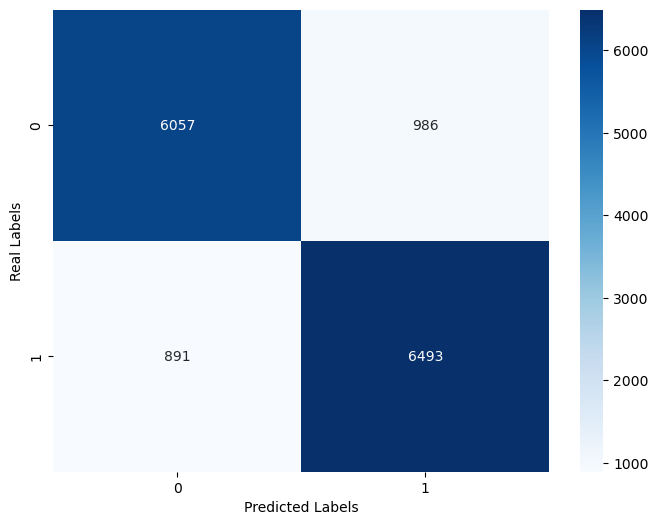

In [64]:
nb_classifier = MultinomialNB()
nb_classifier.fit(count_train, y_train)

pred = nb_classifier.predict(count_test)

print(classification_report(y_test, pred))

plt.figure(figsize = (8,6))

sns.heatmap(
    confusion_matrix(y_test, pred), 
    annot=True, 
    fmt='', 
    cmap='Blues'
)
plt.xlabel('Predicted Labels')
plt.ylabel('Real Labels')

plt.show()

              precision    recall  f1-score   support

           0       0.85      0.73      0.79      7043
           1       0.77      0.88      0.82      7384

    accuracy                           0.81     14427
   macro avg       0.81      0.81      0.81     14427
weighted avg       0.81      0.81      0.81     14427



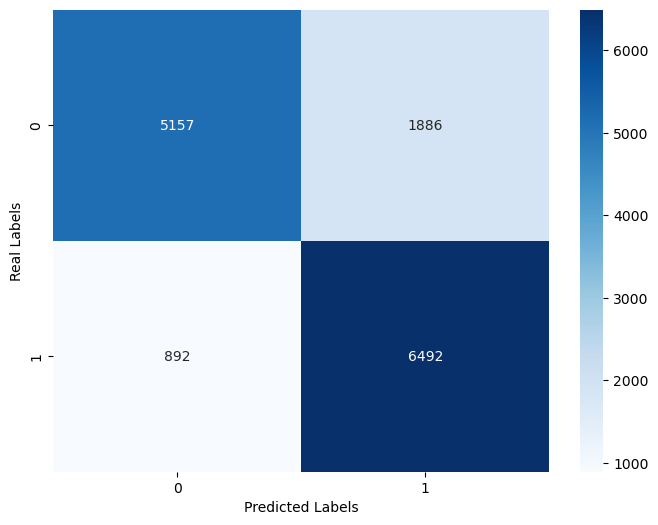

In [65]:
nb_classifier = BernoulliNB()
nb_classifier.fit(count_train, y_train)

pred = nb_classifier.predict(count_test)

print(classification_report(y_test, pred))

plt.figure(figsize = (8,6))

sns.heatmap(
    confusion_matrix(y_test, pred), 
    annot=True, 
    fmt='', 
    cmap='Blues'
)
plt.xlabel('Predicted Labels')
plt.ylabel('Real Labels')

plt.show()